In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# For time series decomposition and forecasting
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("TIME SERIES ANALYSIS - STOCK PRICE DATASET")
print("="*60)

TIME SERIES ANALYSIS - STOCK PRICE DATASET


In [ ]:
# Install dependencies as needed:
!pip install kagglehub[pandas-datasets]
import kagglehub
import pandas as pd
from kagglehub import KaggleDatasetAdapter

In [ ]:
import os
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Dataset identifier
DATASET_ID = "jacksoncrow/stock-market-dataset"

# Download the entire dataset to a local path
# dataset_download returns the path to the root directory of the downloaded dataset
try:
  local_dataset_path = kagglehub.dataset_download(DATASET_ID)
  print(f"Dataset downloaded to: {local_dataset_path}")

  # List files in the downloaded directory to find the correct CSV
  print("Files in the downloaded dataset:")
  for root, dirs, files in os.walk(local_dataset_path):
      for name in files:
          print(os.path.join(root, name))

  # --- After inspecting the output, we'll set the correct file_path here ---
  # The output showed files like 'stocks/PFFL.csv', 'etfs/FLCO.csv', etc.
  # Updating 'file_to_load' to point to an example stock data file.
  file_to_load = "stocks/PFFL.csv" # Changed from "daily_price.csv"

  # Construct the full path to the file
  full_file_path = os.path.join(local_dataset_path, file_to_load)

  # Check if the file exists before attempting to read it
  if not os.path.exists(full_file_path):
      print(f"Warning: The assumed file '{file_to_load}' was not found at '{full_file_path}'.")
      print("Please update 'file_to_load' after reviewing the 'Files in the downloaded dataset:' output.")
  else:
      # Read the CSV file into a pandas DataFrame
      df = pd.read_csv(full_file_path)
      print("First 5 records:", df.head())

except Exception as e:
  print(f"An error occurred during dataset download or file listing: {e}")
  print("Please ensure the dataset ID 'jacksoncrow/stock-market-dataset' is correct.")


100%|██████████| 522M/522M [00:05<00:00, 95.6MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2
Files in the downloaded dataset:
/root/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2/symbols_valid_meta.csv
/root/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2/stocks/PFFL.csv
/root/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2/stocks/NPN.csv
/root/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2/stocks/HCKT.csv
/root/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2/stocks/BEST.csv
/root/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2/stocks/SPLK.csv
/root/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2/stocks/KFFB.csv
/root/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2/stocks/TCX.csv
/root/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2/stocks/UCIB.csv
/root/.cache/kagglehub/datasets/jac

In [ ]:
df.head(10)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-09-26,24.950001,25.030001,24.950001,25.030001,21.401503,5200
1,2018-09-27,25.040001,25.040001,25.040001,25.040001,21.410053,5600
2,2018-09-28,25.070000,25.139999,25.070000,25.110001,21.469906,2100
3,2018-10-01,24.969999,25.400000,24.790001,24.799999,21.204844,52900
4,2018-10-02,24.790001,24.790001,24.680000,24.680000,21.102240,2000
5,2018-10-03,24.590000,24.680000,24.170000,24.209999,20.700371,4200
6,2018-10-04,24.129999,24.129999,23.809999,23.809999,20.358358,20200
7,2018-10-05,23.850000,23.850000,23.820000,23.820000,20.366911,500
8,2018-10-08,23.820000,23.940001,23.820000,23.879999,20.418213,1500
9,2018-10-09,23.969999,23.969999,23.969999,23.969999,20.495165,600


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.resample(rule='A').min()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-12-31,20.709999,20.900000,20.709999,20.900000,18.216024,0
2019-12-31,21.860001,22.309999,21.860001,22.290001,19.427525,100
2020-12-31,4.890000,11.170000,3.000000,5.000000,5.000000,1800


<Axes: xlabel='Date'>

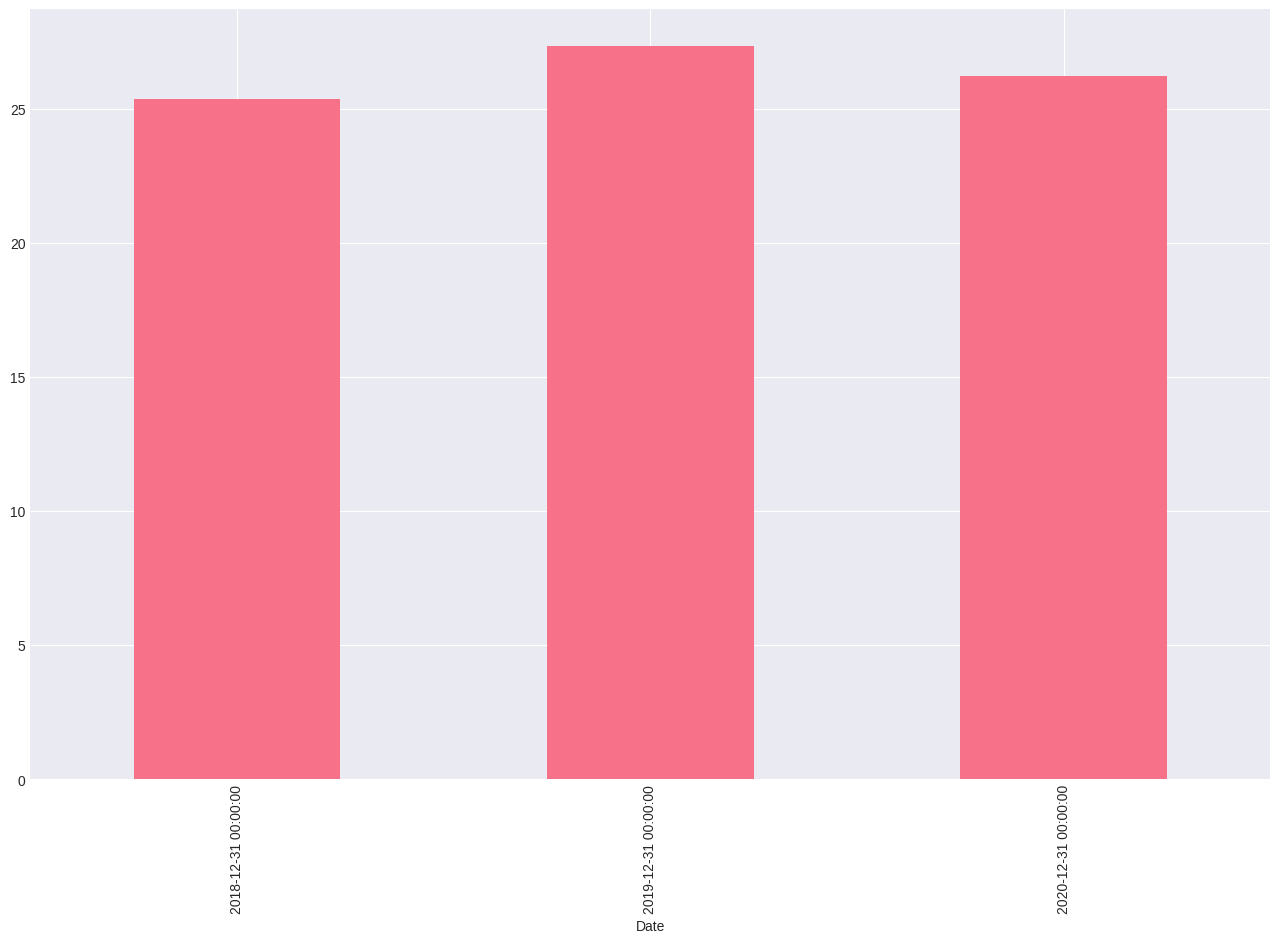

In [ ]:
df.resample(rule='A').max()['Open'].plot(kind='bar')
df.resample(rule='BA').max()['High'].plot(kind='bar',figsize=(16,10))

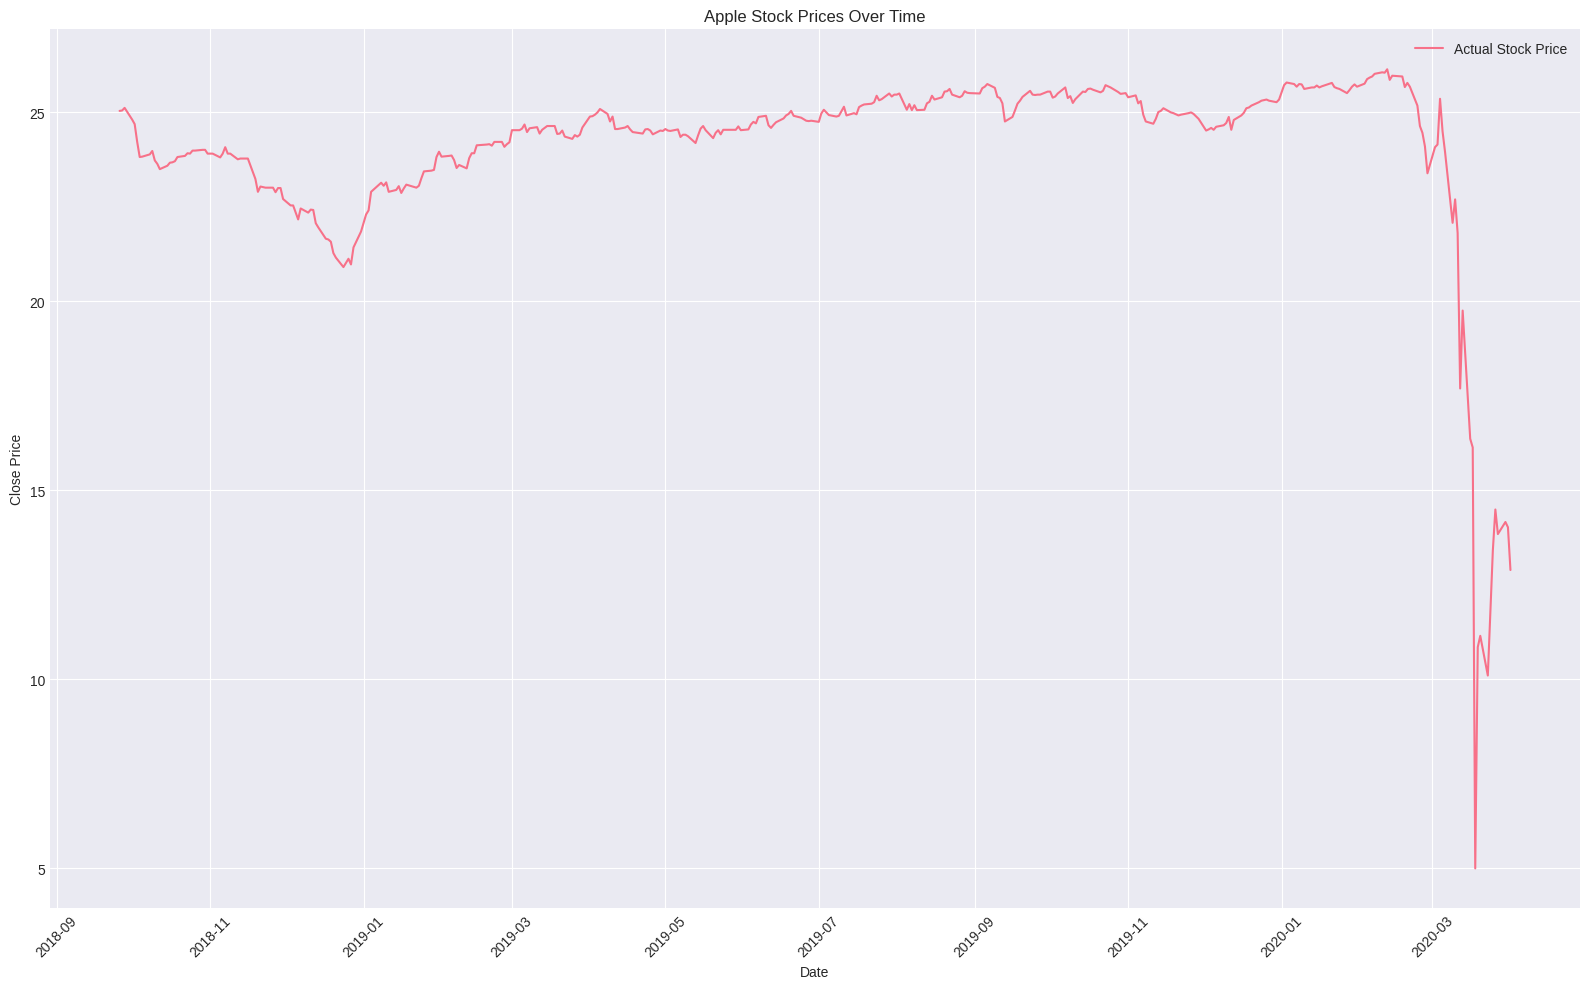

In [ ]:
plt.figure(figsize=(16,10))
plt.plot(df['Close'], label='Actual Stock Price')
plt.title('Apple Stock Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df['Month'] = df.index.month

df.Month.head(15)

,Month
Date,
2018-09-26,9
2018-09-27,9
2018-09-28,9
2018-10-01,10
2018-10-02,10
2018-10-03,10
2018-10-04,10
2018-10-05,10
2018-10-08,10


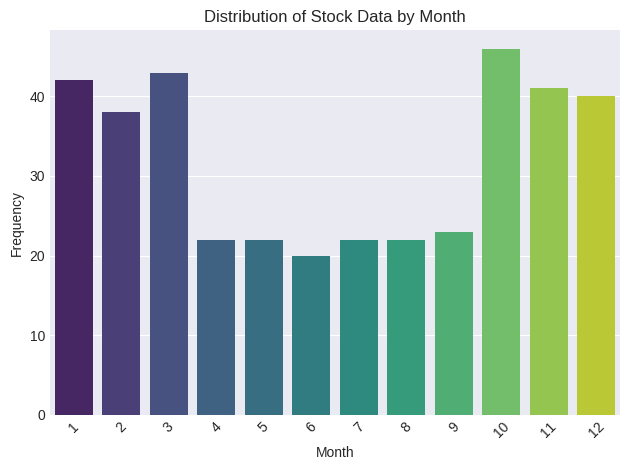

In [ ]:
sns.countplot(x='Month', data=df, palette='viridis')

plt.title('Distribution of Stock Data by Month')
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
df['MA50'] = df['Close'].rolling(50).mean()
df['MA200'] = df['Close'].rolling(200).mean()
df['Previous day close price'] = df['Close'].shift(1)
df['Change in price'] = df['Close'] - df['Previous day close price']
df['Percent change in price'] = df['Close'].pct_change()

In [ ]:
df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
Month,0
MA50,49
MA200,199
Previous day close price,1


In [ ]:
df.fillna(method='bfill', inplace=True)
df.head()

,Open,High,Low,Close,Adj Close,Volume,Month,MA50,MA200,Previous day close price,Change in price,Percent change in price
Date,,,,,,,,,,,,
2018-09-26,24.950001,25.030001,24.950001,25.030001,21.401503,5200,9,23.705,23.94195,25.030001,0.010000,0.000400
2018-09-27,25.040001,25.040001,25.040001,25.040001,21.410053,5600,9,23.705,23.94195,25.030001,0.010000,0.000400
2018-09-28,25.070000,25.139999,25.070000,25.110001,21.469906,2100,9,23.705,23.94195,25.040001,0.070000,0.002796
2018-10-01,24.969999,25.400000,24.790001,24.799999,21.204844,52900,10,23.705,23.94195,25.110001,-0.310001,-0.012346
2018-10-02,24.790001,24.790001,24.680000,24.680000,21.102240,2000,10,23.705,23.94195,24.799999,-0.119999,-0.004839


In [ ]:
df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
Month,0
MA50,0
MA200,0
Previous day close price,0


<Axes: xlabel='Date'>

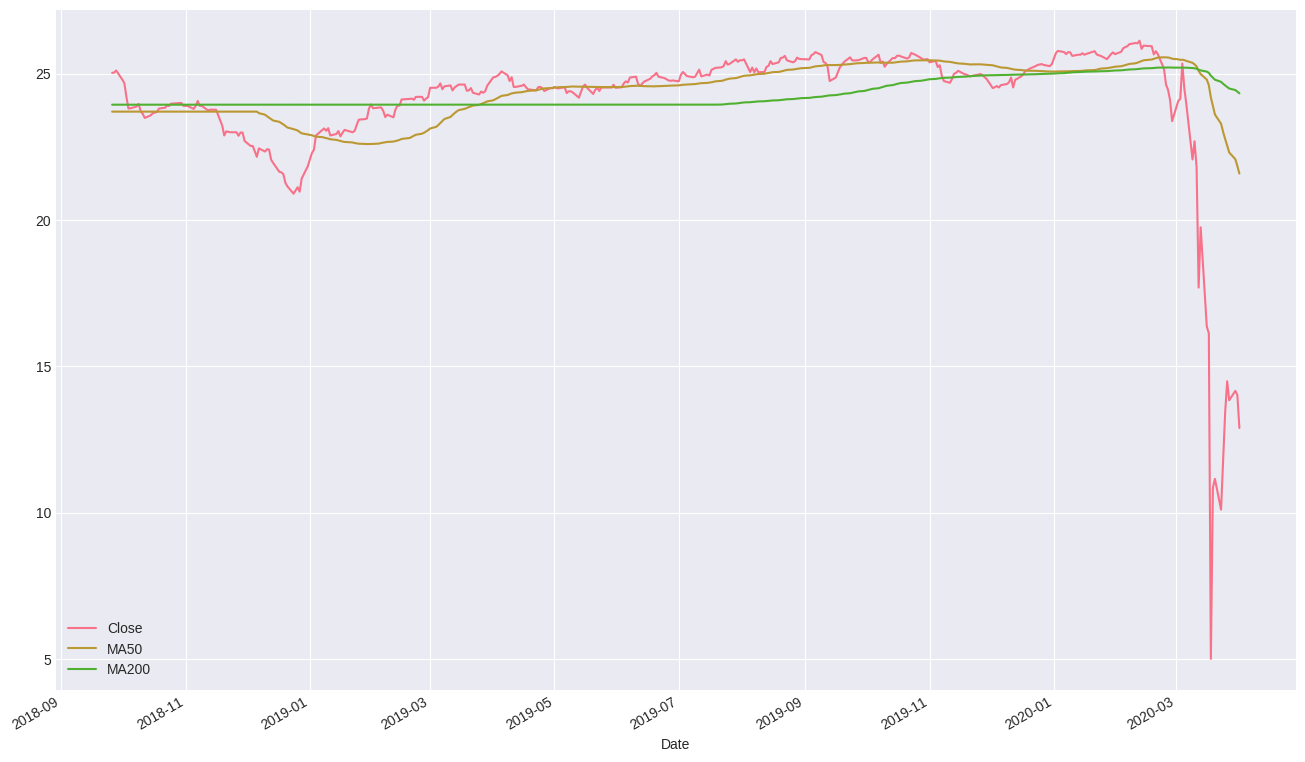

In [ ]:
df[['Close','MA50','MA200']].plot(label='Actual Stock Price',figsize=(16,10))

<Axes: xlabel='Date'>

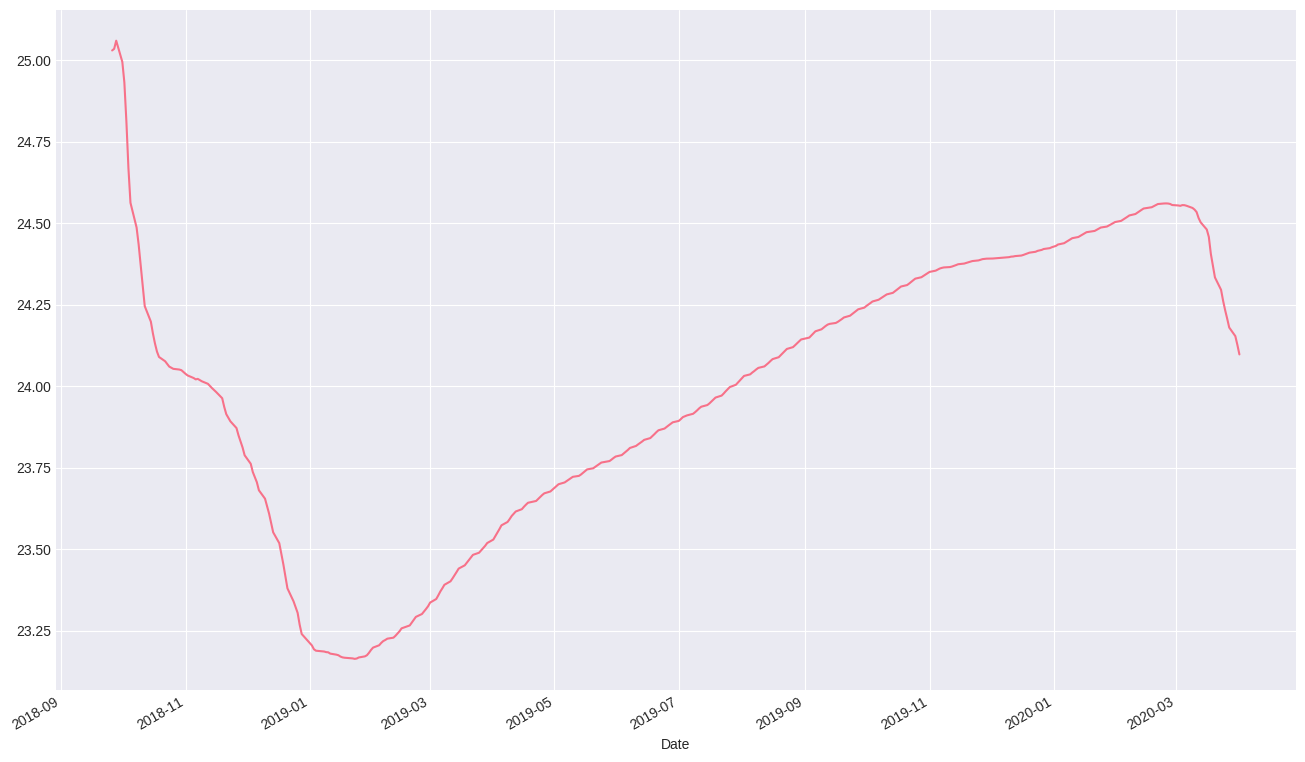

In [ ]:
df.Close.expanding().mean().plot(figsize=(16,10))

In [ ]:
df['EMA']=df.Close.ewm(alpha=0.1,adjust=True).mean()
df.head()

,Open,High,Low,Close,Adj Close,Volume,Month,MA50,MA200,Previous day close price,Change in price,Percent change in price,EMA
Date,,,,,,,,,,,,,
2018-09-26,24.950001,25.030001,24.950001,25.030001,21.401503,5200,9,23.705,23.94195,25.030001,0.010000,0.000400,25.030001
2018-09-27,25.040001,25.040001,25.040001,25.040001,21.410053,5600,9,23.705,23.94195,25.030001,0.010000,0.000400,25.035264
2018-09-28,25.070000,25.139999,25.070000,25.110001,21.469906,2100,9,23.705,23.94195,25.040001,0.070000,0.002796,25.062842
2018-10-01,24.969999,25.400000,24.790001,24.799999,21.204844,52900,10,23.705,23.94195,25.110001,-0.310001,-0.012346,24.986412
2018-10-02,24.790001,24.790001,24.680000,24.680000,21.102240,2000,10,23.705,23.94195,24.799999,-0.119999,-0.004839,24.911588


<Axes: xlabel='Date'>

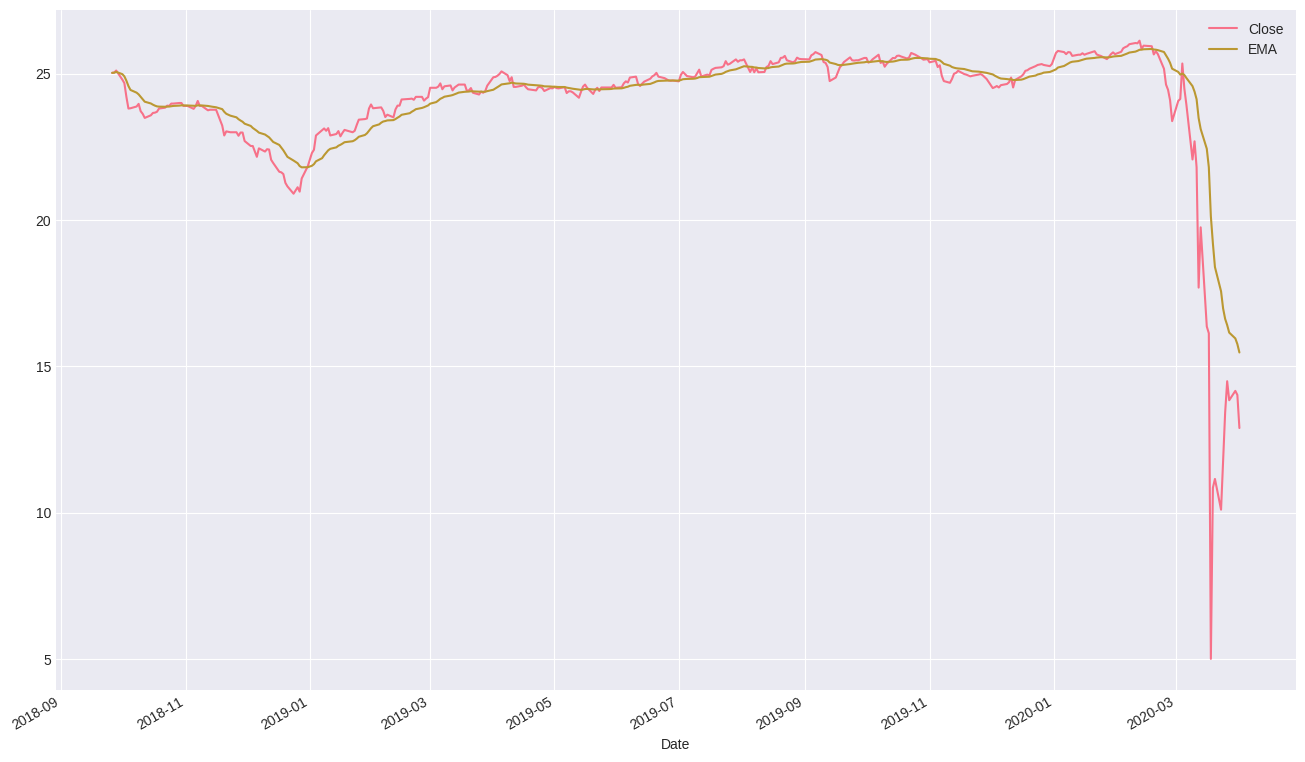

In [ ]:
df[['Close','EMA']].plot(figsize=(16,10))

In [ ]:
df['EWMA']=df.Close.ewm(span=5,adjust=False).mean()
df.head()

,Open,High,Low,Close,Adj Close,Volume,Month,MA50,MA200,Previous day close price,Change in price,Percent change in price,EMA,EWMA
Date,,,,,,,,,,,,,,
2018-09-26,24.950001,25.030001,24.950001,25.030001,21.401503,5200,9,23.705,23.94195,25.030001,0.010000,0.000400,25.030001,25.030001
2018-09-27,25.040001,25.040001,25.040001,25.040001,21.410053,5600,9,23.705,23.94195,25.030001,0.010000,0.000400,25.035264,25.033334
2018-09-28,25.070000,25.139999,25.070000,25.110001,21.469906,2100,9,23.705,23.94195,25.040001,0.070000,0.002796,25.062842,25.058890
2018-10-01,24.969999,25.400000,24.790001,24.799999,21.204844,52900,10,23.705,23.94195,25.110001,-0.310001,-0.012346,24.986412,24.972593
2018-10-02,24.790001,24.790001,24.680000,24.680000,21.102240,2000,10,23.705,23.94195,24.799999,-0.119999,-0.004839,24.911588,24.875062


<Axes: xlabel='Date'>

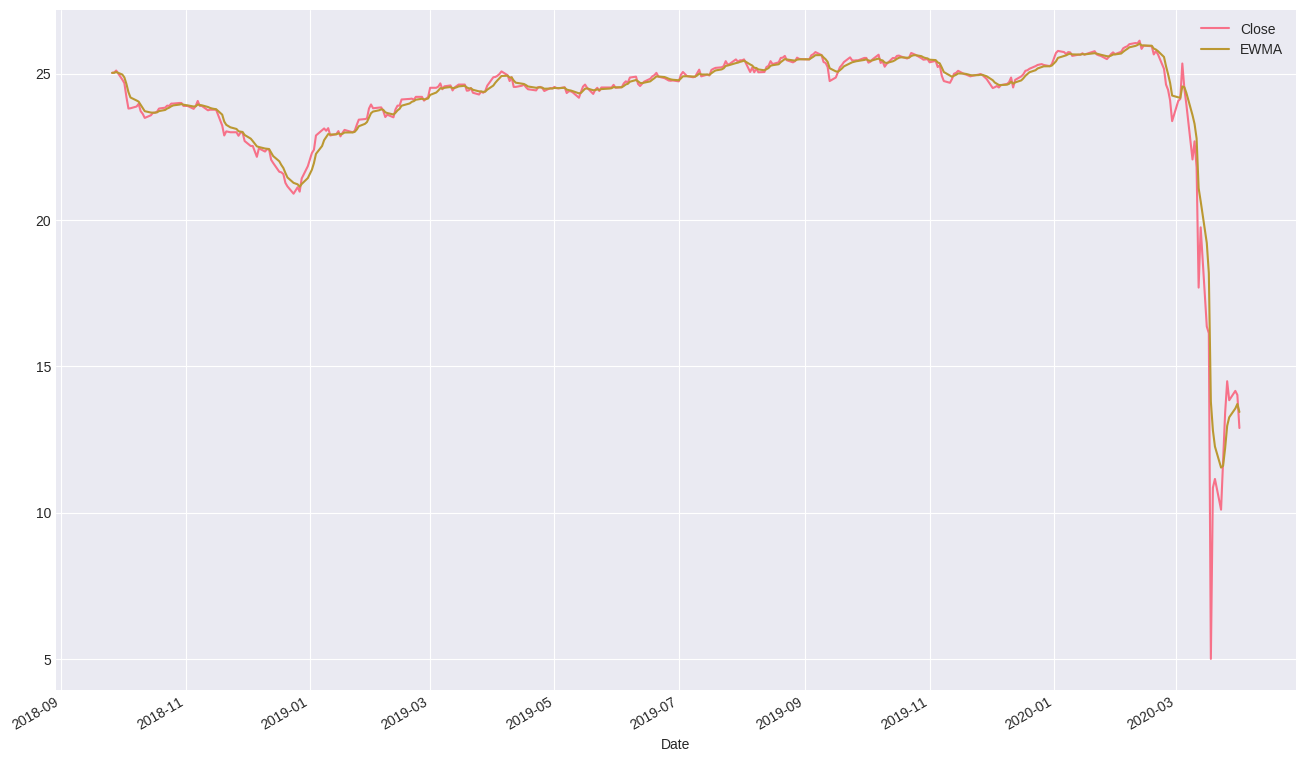

In [ ]:
df[['Close','EWMA']].plot(figsize=(16,10))

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

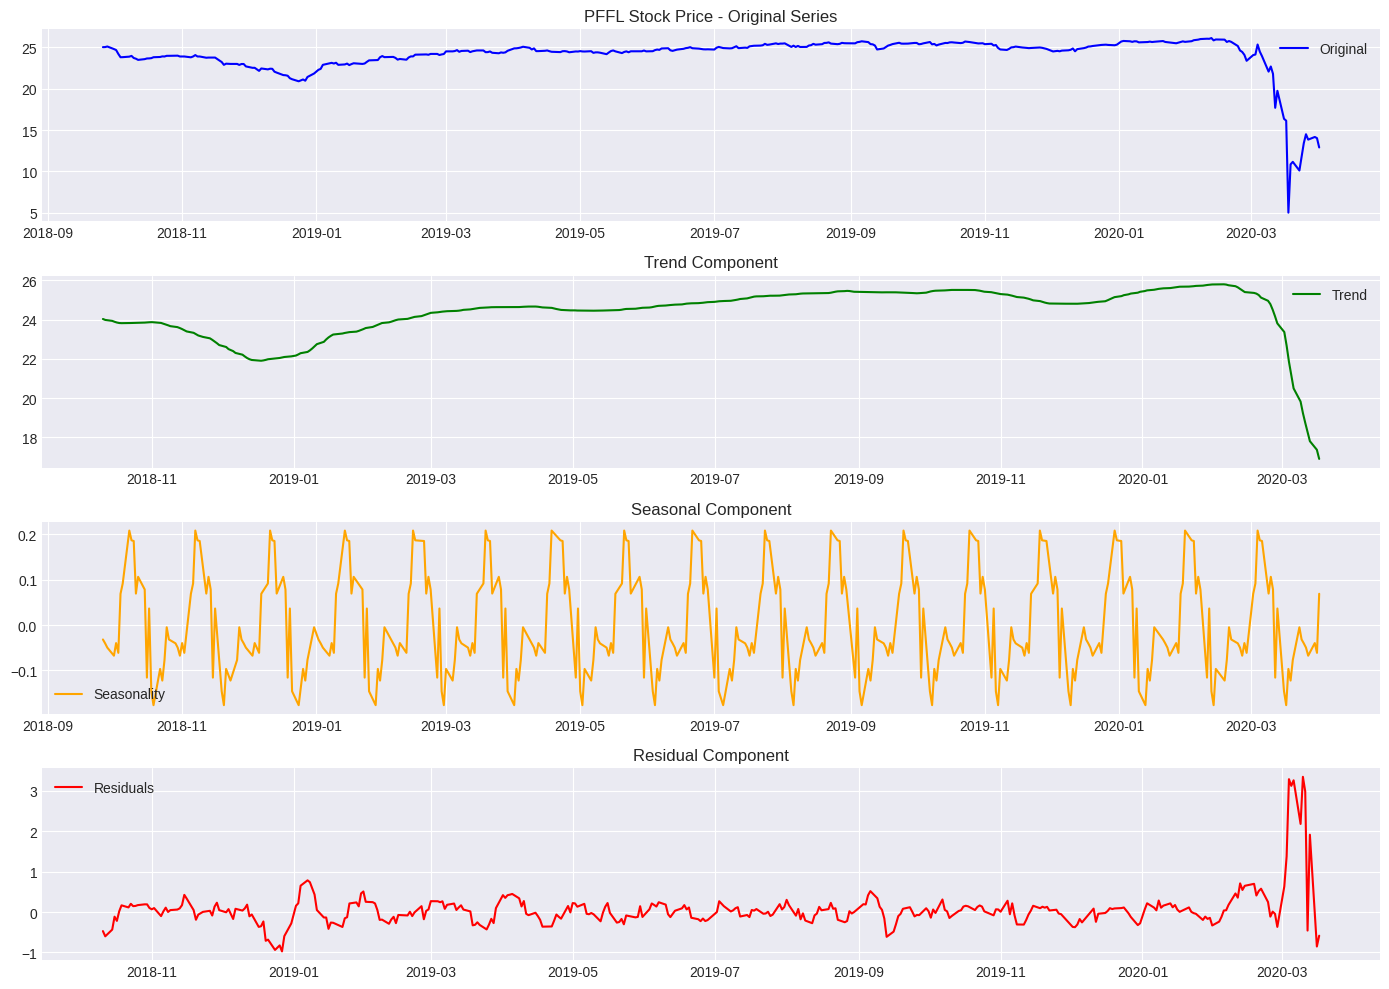

In [ ]:
# Perform seasonal decomposition
def decompose_timeseries(data, model='additive', period=22): # Changed period from 252 to 22 (approx. monthly trading days)
    """Decompose time series into trend, seasonal, and residual components."""
    decomposition = seasonal_decompose(data, model=model, period=period)
    trend = decomposition.trend
    seasonal = decomposition.seasonal
    residual = decomposition.resid
    return decomposition, trend, seasonal, residual

# Define ticker for plot title
ticker = 'PFFL' # Inferred from the loaded file (PFFL.csv)

# Decompose the closing price
decomposition, trend, seasonal, residual = decompose_timeseries(df['Close'])

# Plot the decomposition
plt.figure(figsize=(14, 10))

plt.subplot(411)
plt.plot(df['Close'], label='Original', color='blue')
plt.legend(loc='best')
plt.title(f'{ticker} Stock Price - Original Series')

plt.subplot(412)
plt.plot(trend, label='Trend', color='green')
plt.legend(loc='best')
plt.title('Trend Component')

plt.subplot(413)
plt.plot(seasonal, label='Seasonality', color='orange')
plt.legend(loc='best')
plt.title('Seasonal Component')

plt.subplot(414)
plt.plot(residual, label='Residuals', color='red')
plt.legend(loc='best')
plt.title('Residual Component')

plt.tight_layout()
plt.show()

In [ ]:
def check_stationarity(timeseries, title):
    """Print the Augmented Dickey-Fuller test results."""
    print(f'Results of Dickey-Fuller Test for {title}:')
    dftest = adfuller(timeseries.dropna(), autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
    print(dfoutput)
    if dftest[1] <= 0.05:
        print("Conclusion: The series is likely stationary.")
    else:
        print("Conclusion: The series is likely non-stationary.")

# Check stationarity of original closing price
check_stationarity(df.Close, "Original Closing Price")

Results of Dickey-Fuller Test for Original Closing Price:
Test Statistic                  -1.720720
p-value                          0.420470
#Lags Used                      17.000000
Number of Observations Used    363.000000
Critical Value (1%)             -3.448494
Critical Value (5%)             -2.869535
Critical Value (10%)            -2.571029
dtype: float64
Conclusion: The series is likely non-stationary.


Results of Dickey-Fuller Test for Differenced Closing Price:
Test Statistic                  -0.200011
p-value                          0.938520
#Lags Used                      17.000000
Number of Observations Used    362.000000
Critical Value (1%)             -3.448544
Critical Value (5%)             -2.869557
Critical Value (10%)            -2.571041
dtype: float64
Conclusion: The series is likely non-stationary.


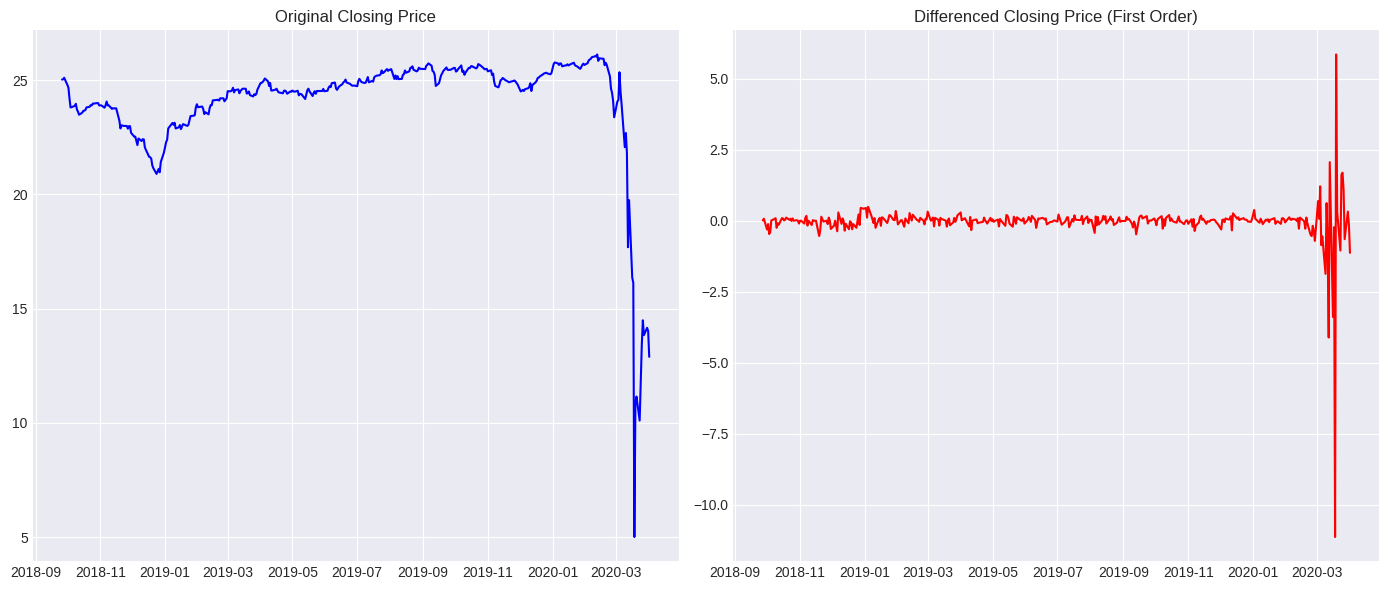

In [ ]:
# Apply differencing
close_price_diff = df.Close.diff().dropna()

# Check stationarity of the differenced series
check_stationarity(close_price_diff, "Differenced Closing Price")

# Plot original vs differenced series
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(df.Close, color='blue')
plt.title('Original Closing Price')
plt.subplot(1, 2, 2)
plt.plot(close_price_diff, color='red')
plt.title('Differenced Closing Price (First Order)')
plt.tight_layout()
plt.show()

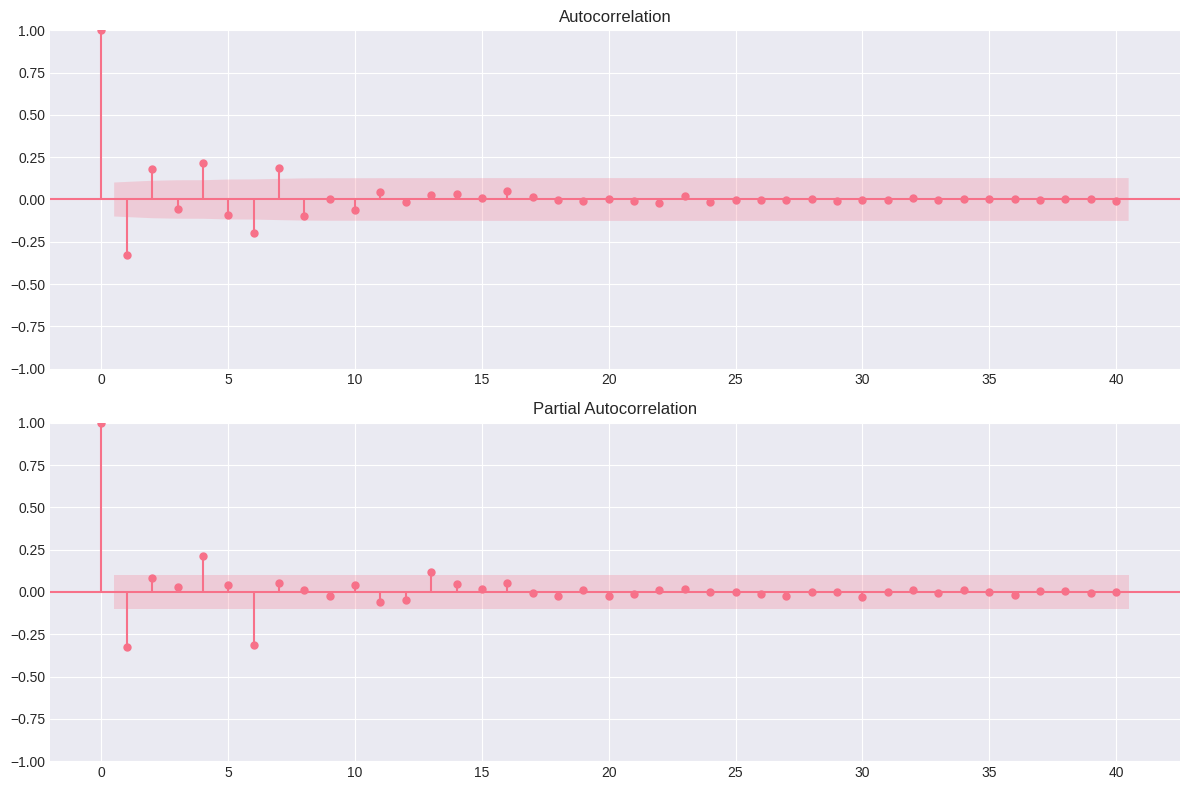

In [ ]:
# Plot ACF and PACF for the differenced series
def plot_acf_pacf(series, lags=40):
    """Plot ACF and PACF."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    plot_acf(series, ax=ax1, lags=lags)
    plot_pacf(series, ax=ax2, lags=lags)
    plt.tight_layout()
    plt.show()

# Plot for the differenced series to identify potential patterns
plot_acf_pacf(close_price_diff)

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.3 MB/s eta 0:00:00


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  381
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -400.209
Date:                Fri, 29 May 2026   AIC                            812.418
Time:                        05:59:48   BIC                            836.059
Sample:                             0   HQIC                           821.799
                                - 381                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3161      0.022    -14.488      0.000      -0.359      -0.273
ar.L2          0.0694      0.017      4.131      0.000       0.036       0.102
ar.L3          0.0919      0.040      2.276      0.0

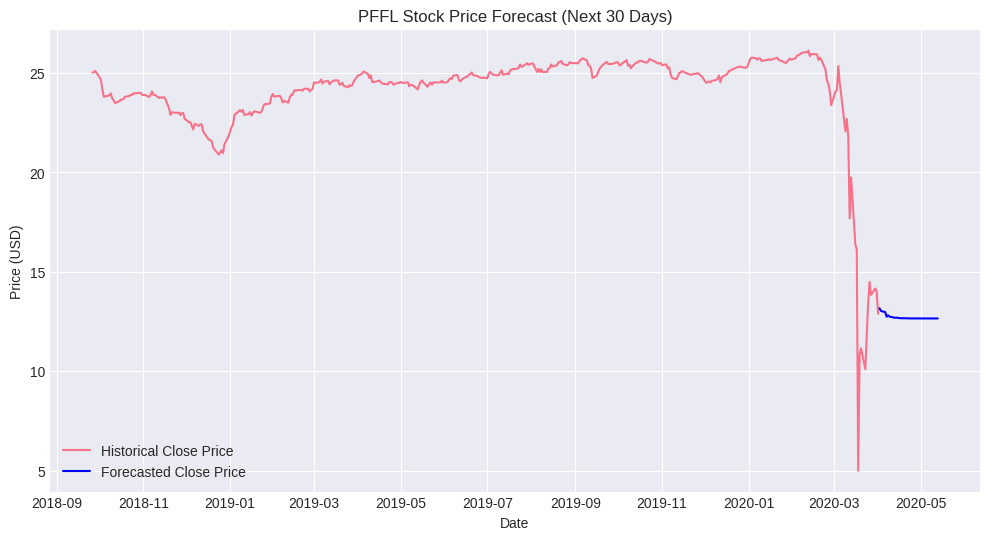

In [ ]:
from pmdarima import auto_arima

# For demonstration, we'll manually specify ARIMA(5,1,0) based on typical patterns
model = ARIMA(df.Close, order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

# Make predictions
forecast_steps = 30
forecast = model_fit.forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=df.Close.index[-1], periods=forecast_steps+1, freq='B')[1:]

# Plot historical data and forecast
plt.figure(figsize=(12, 6))
plt.plot(df.Close.index, df.Close, label='Historical Close Price')
plt.plot(forecast_index, forecast, label='Forecasted Close Price', color='blue')
plt.title(f'{ticker} Stock Price Forecast (Next 30 Days)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

Heads of the Dummy series (100,)
2025-01-01    99.040611
2025-01-02    97.749905
2025-01-03    97.489061
2025-01-04    97.207942
2025-01-05    96.954918
Freq: D, dtype: float64
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -145.126
Date:                Fri, 29 May 2026   AIC                            302.253
Time:                        06:27:53   BIC                            317.824
Sample:                    01-01-2025   HQIC                           308.553
                         - 04-10-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0931      0.091 

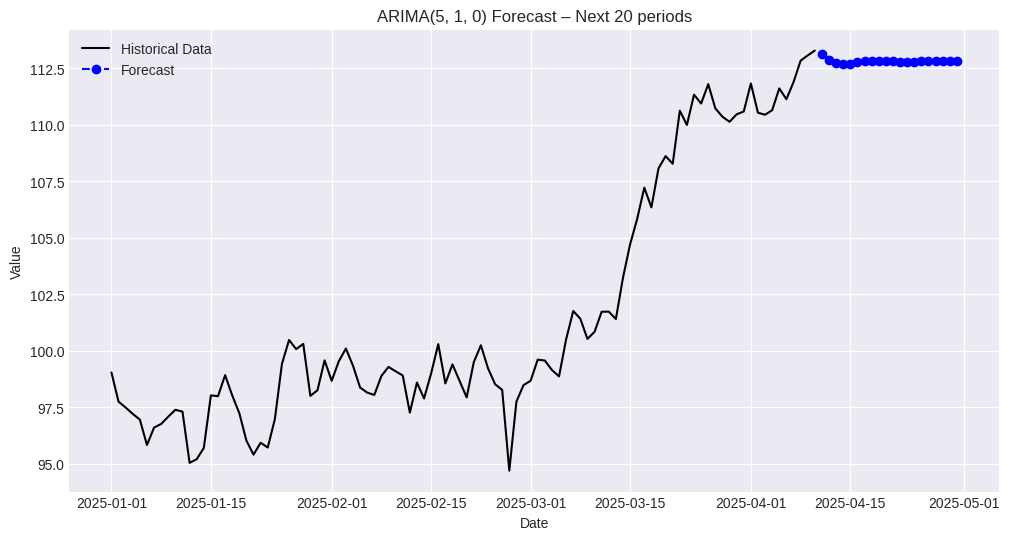

(2025-04-11    113.148288
 2025-04-12    112.878382
 2025-04-13    112.748216
 2025-04-14    112.682627
 2025-04-15    112.699005
 2025-04-16    112.771564
 2025-04-17    112.822188
 2025-04-18    112.847204
 2025-04-19    112.848430
 2025-04-20    112.830673
 2025-04-21    112.813512
 2025-04-22    112.803891
 2025-04-23    112.801701
 2025-04-24    112.805652
 2025-04-25    112.810936
 2025-04-26    112.814458
 2025-04-27    112.815696
 2025-04-28    112.814963
 2025-04-29    112.813453
 2025-04-30    112.812242
 Freq: D, Name: predicted_mean, dtype: float64,
 <statsmodels.tsa.arima.model.ARIMAResultsWrapper at 0x785b38c10230>)

In [ ]:
def forecast_arima(data, forecast_steps=30, order=(5,1,0), freq='B'):
    """
    Fit ARIMA(order) to data and forecast.

    Parameters:
    - data: pandas Series (datetime index)
    - forecast_steps: int, number of steps to forecast
    - order: tuple (p,d,q) for ARIMA
    - freq: frequency code for forecast index ('B'=business days, 'D'=calendar days, etc.)
    """
    # Ensure data is a Series
    if isinstance(data, pd.DataFrame):
        data = data.iloc[:,0]   # take first column if DataFrame

    # Fit ARIMA model
    model = ARIMA(data, order=order)
    model_fit = model.fit()

    # Print model summary (optional)
    print(model_fit.summary())

    # Generate forecast
    forecast = model_fit.forecast(steps=forecast_steps)

    # Create index for forecasted dates
    last_date = data.index[-1]
    forecast_index = pd.date_range(start=last_date, periods=forecast_steps+1, freq=freq)[1:]

    # Plot
    plt.figure(figsize=(12,6))
    plt.plot(data.index, data, label='Historical Data', color='black')
    plt.plot(forecast_index, forecast, label='Forecast', color='blue', linestyle='--', marker='o')
    plt.title(f'ARIMA{order} Forecast – Next {forecast_steps} periods')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()

    return forecast, model_fit# Create a dummy series
dates = pd.date_range('2025-01-01', periods=100, freq='D')
values = np.cumsum(np.random.randn(100)) + 100   # random walk
dummy_series = pd.Series(values, index=dates)
print('Heads of the Dummy series', dummy_series.shape)
print(dummy_series.head())

forecast_arima(dummy_series, forecast_steps=20, freq='D')

                               SARIMAX Results                                
Dep. Variable:                   Open   No. Observations:                  381
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -393.331
Date:                Fri, 29 May 2026   AIC                            798.661
Time:                        06:24:49   BIC                            822.302
Sample:                             0   HQIC                           808.042
                                - 381                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2813      0.015    -18.150      0.000      -0.312      -0.251
ar.L2      -3.655e-05      0.023     -0.002      0.999      -0.044       0.044
ar.L3          0.2138      0.041      5.231      0.0

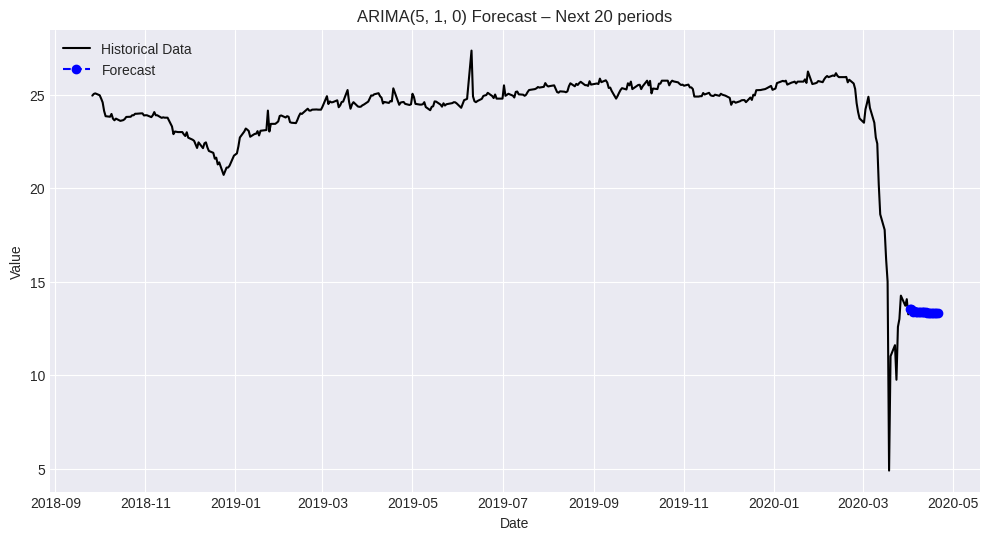

(381    13.514471
 382    13.549505
 383    13.362959
 384    13.416985
 385    13.378513
 386    13.371404
 387    13.369099
 388    13.353758
 389    13.356560
 390    13.351887
 391    13.349196
 392    13.348885
 393    13.347174
 394    13.346817
 395    13.346260
 396    13.345832
 397    13.345686
 398    13.345453
 399    13.345347
 400    13.345265
 Name: predicted_mean, dtype: float64,
 <statsmodels.tsa.arima.model.ARIMAResultsWrapper at 0x785b394ed5b0>)

In [ ]:
forecast_arima(df, forecast_steps=20, freq='D')